In [1]:
import pandas as pd
import numpy as np

!pip install openpyxl

In [2]:
df = pd.read_excel("Telco.xlsx")

In [3]:
print(df.shape)


(7043, 33)


In [4]:
df.head()


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

In [6]:
drop_cols = [
    'CustomerID',
    'Count',
    'Churn Label',
    'Churn Score',
    'Churn Reason',
    'Zip Code',
    'Lat Long',
    'Latitude',
    'Longitude'
]

df = df.drop(columns=drop_cols, errors='ignore')

In [7]:
print(df.shape)

(7043, 24)


In [8]:
# rename for clarity
df.rename(columns={'Churn Value': 'Churn'}, inplace=True)

# check distribution
print(df['Churn'].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [9]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

# fill missing with 0 (or median if you prefer)
df.fillna({'Total Charges': 0}, inplace=True)

,Country,State,City,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,...,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn,CLTV
0,United States,California,Los Angeles,Male,No,No,No,2,Yes,No,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,3239
1,United States,California,Los Angeles,Female,No,No,Yes,2,Yes,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,2701
2,United States,California,Los Angeles,Female,No,No,Yes,8,Yes,Yes,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1,5372
3,United States,California,Los Angeles,Female,No,Yes,Yes,28,Yes,Yes,...,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1,5003
4,United States,California,Los Angeles,Male,No,No,Yes,49,Yes,Yes,...,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1,5340
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,United States,California,Landers,Female,No,No,No,72,Yes,No,...,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.40,0,5306
7039,United States,California,Adelanto,Male,No,Yes,Yes,24,Yes,Yes,...,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,0,2140
7040,United States,California,Amboy,Female,No,Yes,Yes,72,Yes,Yes,...,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,0,5560
7041,United States,California,Angelus Oaks,Female,No,Yes,Yes,11,No,No phone service,...,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,0,2793


In [10]:
cat_cols = df.select_dtypes(include=['object', 'string']).columns
print(cat_cols)

Index(['Country', 'State', 'City', 'Gender', 'Senior Citizen', 'Partner',
       'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method'],
      dtype='str')


In [11]:
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [12]:
!pip install scikit-learn

In [13]:
from sklearn.preprocessing import StandardScaler

In [14]:
scaler = StandardScaler()

num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_cols = num_cols.drop('Churn')  # don't scale target

df[num_cols] = scaler.fit_transform(df[num_cols])

In [15]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
df.corr()['Churn'].sort_values(ascending=False)

Churn                               1.000000
Internet Service_Fiber optic        0.308020
Payment Method_Electronic check     0.301919
Monthly Charges                     0.193356
Paperless Billing_Yes               0.191825
                                      ...   
Tech Support_No internet service   -0.227890
Streaming TV_No internet service   -0.227890
Dependents_Yes                     -0.248542
Contract_Two year                  -0.302253
Tenure Months                      -0.352229
Name: Churn, Length: 1160, dtype: float64

In [17]:
df['Churn'].value_counts(normalize=True) * 100

Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64

In [18]:
!pip install seaborn

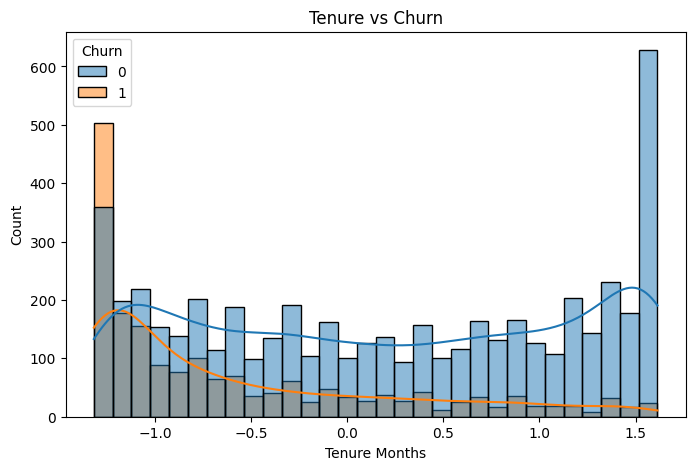

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Tenure Months', hue='Churn', bins=30, kde=True)
plt.title("Tenure vs Churn")
plt.show()

In [20]:
df_original = pd.read_excel("Telco.xlsx")

In [21]:
df_original.rename(columns={'Churn Value': 'Churn'}, inplace=True)

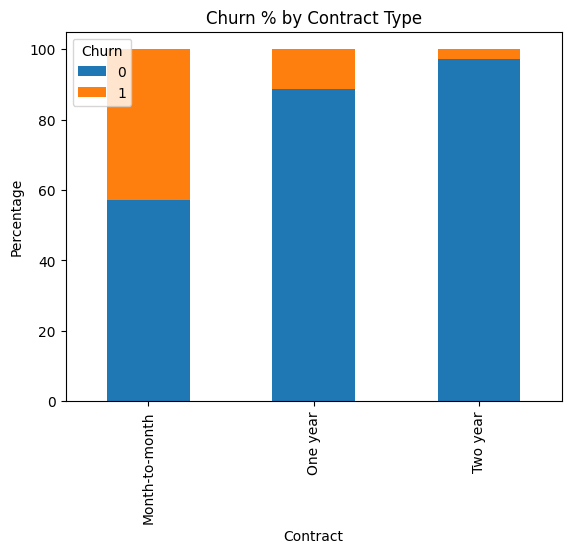

In [22]:
contract_churn = pd.crosstab(df_original['Contract'], df_original['Churn'], normalize='index') * 100
contract_churn.plot(kind='bar', stacked=True)

plt.title("Churn % by Contract Type")
plt.ylabel("Percentage")
plt.show()

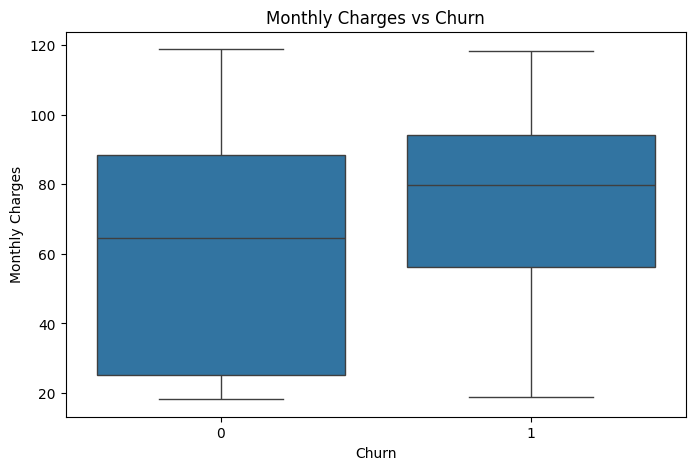

In [23]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='Monthly Charges', data=df_original)
plt.title("Monthly Charges vs Churn")
plt.show()

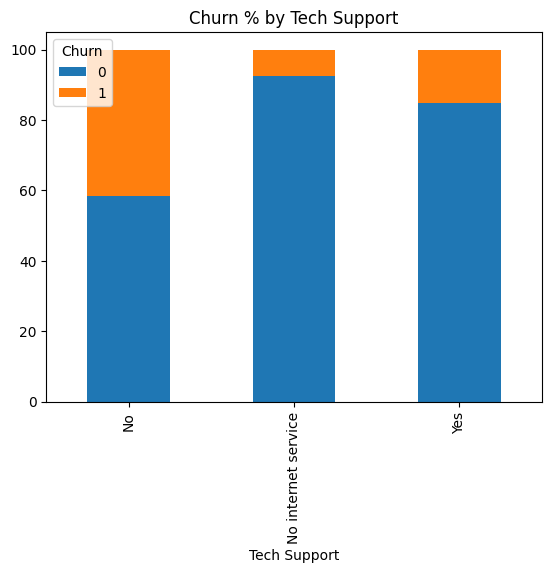

In [24]:
support_churn = pd.crosstab(df_original['Tech Support'], df_original['Churn'], normalize='index') * 100
support_churn.plot(kind='bar', stacked=True)

plt.title("Churn % by Tech Support")
plt.show()

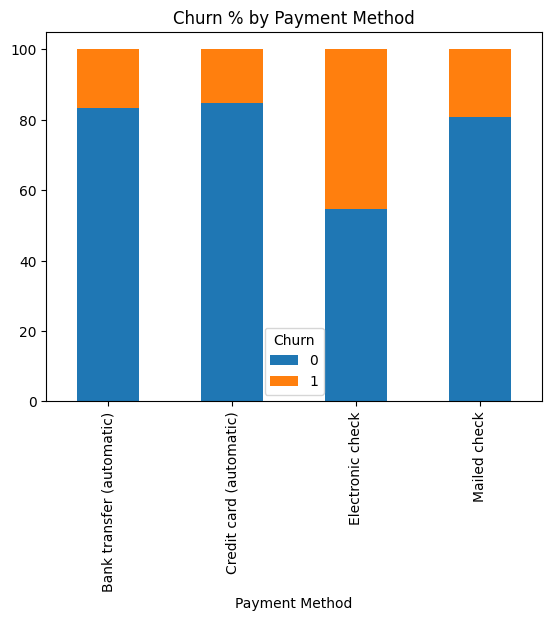

In [25]:
payment_churn = pd.crosstab(df_original['Payment Method'], df_original['Churn'], normalize='index') * 100
payment_churn.plot(kind='bar', stacked=True)

plt.title("Churn % by Payment Method")
plt.show()

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_prob = model.predict_proba(X_test)[:,1]

print(min(y_prob), max(y_prob))


0.00014585836830546397 0.9266491809004662


In [27]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
# default
y_pred_default = (y_prob > 0.5).astype(int)

# lower threshold
y_pred_03 = (y_prob > 0.3).astype(int)

from sklearn.metrics import confusion_matrix

print("Default:\n", confusion_matrix(y_test, y_pred_default))
print("\nThreshold 0.3:\n", confusion_matrix(y_test, y_pred_03))

Default:
 [[895 114]
 [173 227]]

Threshold 0.3:
 [[778 231]
 [105 295]]


In [29]:
from sklearn.metrics import accuracy_score, classification_report

In [30]:
print("Accuracy:", accuracy_score(y_test, y_pred_03))
print("\nClassification Report:\n", classification_report(y_test, y_pred_03))

Accuracy: 0.7615330021291696

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.77      0.82      1009
           1       0.56      0.74      0.64       400

    accuracy                           0.76      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.79      0.76      0.77      1409



In [31]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy (0.3):", accuracy_score(y_test, y_pred_03))
print("\nClassification Report (0.3):\n", classification_report(y_test, y_pred_03))

Accuracy (0.3): 0.7615330021291696

Classification Report (0.3):
               precision    recall  f1-score   support

           0       0.88      0.77      0.82      1009
           1       0.56      0.74      0.64       400

    accuracy                           0.76      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.79      0.76      0.77      1409



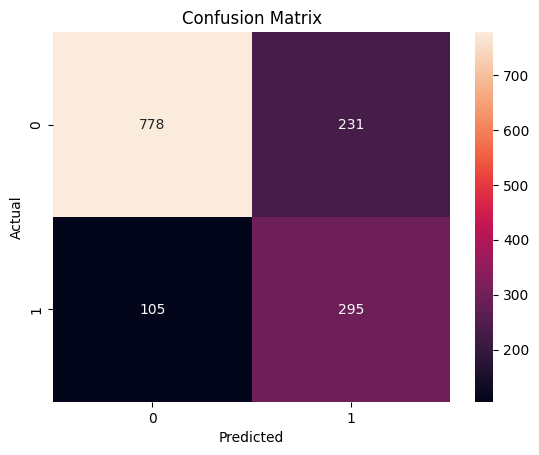

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_03)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [33]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.coef_[0]
})

coefficients = coefficients.sort_values(by='Importance', ascending=False)
coefficients.head(10)

,Feature,Importance
945,City_Smith River,1.557149
873,City_San Dimas,1.398090
241,City_Cupertino,1.321725
757,City_Pearblossom,1.299269
306,City_Emeryville,1.281180
253,City_Deer Park,1.174480
1032,City_Tujunga,1.158381
721,City_Orangevale,1.120080
303,City_Elk Grove,1.111578
108,City_Boulder Creek,1.082143


In [34]:
coefficients.head(10)

,Feature,Importance
945,City_Smith River,1.557149
873,City_San Dimas,1.398090
241,City_Cupertino,1.321725
757,City_Pearblossom,1.299269
306,City_Emeryville,1.281180
253,City_Deer Park,1.174480
1032,City_Tujunga,1.158381
721,City_Orangevale,1.120080
303,City_Elk Grove,1.111578
108,City_Boulder Creek,1.082143


In [35]:
cols_to_drop = [col for col in df.columns if 'City_' in col]

df = df.drop(columns=cols_to_drop)

In [36]:
df = df.drop(columns=['State', 'Country'], errors='ignore')

In [37]:
coefficients.head(10)

,Feature,Importance
945,City_Smith River,1.557149
873,City_San Dimas,1.398090
241,City_Cupertino,1.321725
757,City_Pearblossom,1.299269
306,City_Emeryville,1.281180
253,City_Deer Park,1.174480
1032,City_Tujunga,1.158381
721,City_Orangevale,1.120080
303,City_Elk Grove,1.111578
108,City_Boulder Creek,1.082143


In [38]:
import joblib
joblib.dump(model, "churn_model.pkl")

['churn_model.pkl']

In [39]:
!pip install psycopg2-binary sqlalchemy

In [40]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus

username = "postgres"
password = quote_plus("justin@1234")
host = "localhost"
port = "5432"
database = "churn_ibm"   # ✅ FIXED

engine = create_engine(
    f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}"
)

In [41]:
engine.connect()
print("Connected ✅")

Connected ✅


In [42]:
df_original.columns = df_original.columns.str.lower().str.replace(' ', '_')

df_original.to_sql("customers_raw", engine, if_exists="replace", index=False)

113